# Dr. Case Notebook
# Intro to Web Mining & Applied NLP

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

- Author: [Houston Asher-Laws](https://github.com/hasherlaws18/)
- Repository: [nlp-01-getting-started](https://github.com/hasherlaws18/nlp-01-getting-started/)
- Purpose: Demonstrate web mining and applied natural language processing (NLP)
- Date: 2026-03

This is a Markdown cell.

## Section 0. Intro to Jupyter Notebooks

This is a Markdown cell. 
Tips for Jupyter Notebooks:

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) after editing the cell.
- Change the type of a cell (e.g., to code or markdown) by looking in the lower edge of the cell interface.
- Rearrange cells by dragging and dropping cells.
- Use **File > Save as** to rename and save a notebook. 
- You must select a kernel (Python environment) for your notebook. In VS Code, click **Select Kernel** in the top-right corner of the notebook interface and choose the desired kernel from the dropdown menu. 
- Follow suggestions to install recommended extensions.
- Once installed, click Select Kernel / Python Environments and choose the Recommended `.venv` option created for the project. This creates a new kernel for the notebook to run code using the packages installed in the local `.venv`.

TODO: Delete this cell or make your own notes.

## Section 1. Setup and Imports

Imports and configuration appear once, at the top.

WHY:
- Keeps notebooks readable and reproducible
- Mirrors professional scripts
- Makes requirements clear

This is a Markdown cell.

In [17]:
# Section 1 Python cell.

# Imports at the top of the file
# REQ: External packages must be defined in pyproject.toml
# REQ: External packages must be installed in the environment using `uv sync` command
# REQ: External packages used in this notebook must be imported here

from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import polars as pl
import requests
from wordcloud import WordCloud

print("Imports complete.")

Imports complete.


## Section 2. Retrieve a Web Page (as HTML text)

This is a Markdown cell.

In [18]:
# Section 2 Python cell

# Choose a page to analyze.
# The Shakespeare page is simple and stable.
# The Wikipedia page is interesting, but requires a User-Agent header.
# url: str = "https://shakespeare.mit.edu/romeo_juliet/full.html"
url: str = "https://en.wikipedia.org/wiki/Natural_language_processing"

# Some sites reject requests that look like anonymous scripts.
# This header helps the request look more like a normal browser visit.
headers: dict[str, str] = {
    "User-Agent": "Mozilla/5.0 (compatible; NLP-Course-Example/1.0)"
}

# Request the page and stop with an error if the request fails.
response = requests.get(url, headers=headers, timeout=30)
response.raise_for_status()

# Store the raw HTML text.
html: str = response.text

print(f"Downloaded {len(html):,} characters from:")
print(url)

Downloaded 323,098 characters from:
https://en.wikipedia.org/wiki/Natural_language_processing


## Section 3. Parse the HTML (into a BeautifulSoup tree)

This is a Markdown cell.

In [19]:
# Section 3 Python cell

# BeautifulSoup() takes raw HTML text
# and builds a parse tree (a structured representation of the document)
# we assign to a variable named soup (short for "soup of tags").

# Example Input:
# "<html><body><p>Hello</p></body></html>"

# Example BeautifulSoup parse tree:
# html
#  └── body
#       └── p
#            └── "Hello"

# This makes it easier to extract text and inspect page structure.

# Call BeautifulSoup with the raw HTML and a parser (lxml is fast and lenient).
soup: BeautifulSoup = BeautifulSoup(html, "lxml")

print("HTML parsed successfully.")
print(type(soup))

HTML parsed successfully.
<class 'bs4.BeautifulSoup'>


## Section 4. Extract Visible Text from the HTML

This is a Markdown cell.

In [20]:
# Section 4 Python cell

# Extract visible text from the page with get_text() method.
# separator=" " inserts spaces between chunks of text.
# strip=True removes leading and trailing whitespace.
text: str = soup.get_text(separator=" ", strip=True)

# Use [0:1000] to show only the first 1000 characters of the text.
# Or [:1000] gives the same result, since the start index defaults to 0.
print("First 1000 characters of extracted text:")
print(text[:1000])

First 1000 characters of extracted text:
Natural language processing - Wikipedia Jump to content Main menu Main menu move to sidebar hide Navigation Main page Contents Current events Random article About Wikipedia Contact us Contribute Help Learn to edit Community portal Recent changes Upload file Special pages Search Search Appearance Donate Create account Log in Personal tools Donate Create account Log in Contents move to sidebar hide (Top) 1 History Toggle History subsection 1.1 Symbolic NLP (1950s – early 1990s) 1.2 Statistical NLP (1990s–present) 2 Approaches: Symbolic, statistical, neural networks Toggle Approaches: Symbolic, statistical, neural networks subsection 2.1 Statistical approach 2.2 Neural networks 3 Common NLP tasks Toggle Common NLP tasks subsection 3.1 Text and speech processing 3.2 Morphological analysis 3.3 Syntactic analysis 3.4 Lexical semantics (of individual words in context) 3.5 Relational semantics (semantics of individual sentences) 3.6 Discourse (semantics

## Section 5. Clean the Text (split, lowercase, remove punctuation)

This is a Markdown cell.

In [21]:
# Section 5 Python cell

# Split the text into words
words = text.split()

# Print the first 20 words and the total number of words
print(words[:20])
print(len(words))

# Convert to lowercase
words = [w.lower() for w in words]

# Remove punctuation and short tokens
clean_words = [w.strip(".,:;!?()[]\"'") for w in words if len(w) > 3]

['Natural', 'language', 'processing', '-', 'Wikipedia', 'Jump', 'to', 'content', 'Main', 'menu', 'Main', 'menu', 'move', 'to', 'sidebar', 'hide', 'Navigation', 'Main', 'page', 'Contents']
8219


## Section 6. Build a Frequency Table (Polars)


This is a Markdown cell.

In [22]:
# Section 6 Python cell

# For working with tabular data,
# Polars is faster and smaller than pandas,
# has a more modern API, and the concepts are similar.

# Create a Polars DataFrame (df) with one row per word with a column named "word".
df: pl.DataFrame = pl.DataFrame({"word": clean_words})

# Group by word, count occurrences, and sort from most common to least common.
# This is a powerful pattern for counting and summarizing data in Polars.
# Function chain: group_by() -> len() -> sort()
freq_df: pl.DataFrame = df.group_by("word").len().sort("len", descending=True)

print("Top 20 most frequent words:")
print(freq_df.head(20))

Top 20 most frequent words:
shape: (20, 2)
┌────────────┬─────┐
│ word       ┆ len │
│ ---        ┆ --- │
│ str        ┆ u64 │
╞════════════╪═════╡
│ language   ┆ 110 │
│ natural    ┆ 69  │
│ processing ┆ 54  │
│ text       ┆ 51  │
│ that       ┆ 41  │
│ …          ┆ …   │
│ given      ┆ 25  │
│ retrieved  ┆ 25  │
│ edit       ┆ 25  │
│ speech     ┆ 24  │
│ neural     ┆ 23  │
└────────────┴─────┘


## Section 7. Build "Most Frequent Words" Bar Chart

This is a Markdown cell.

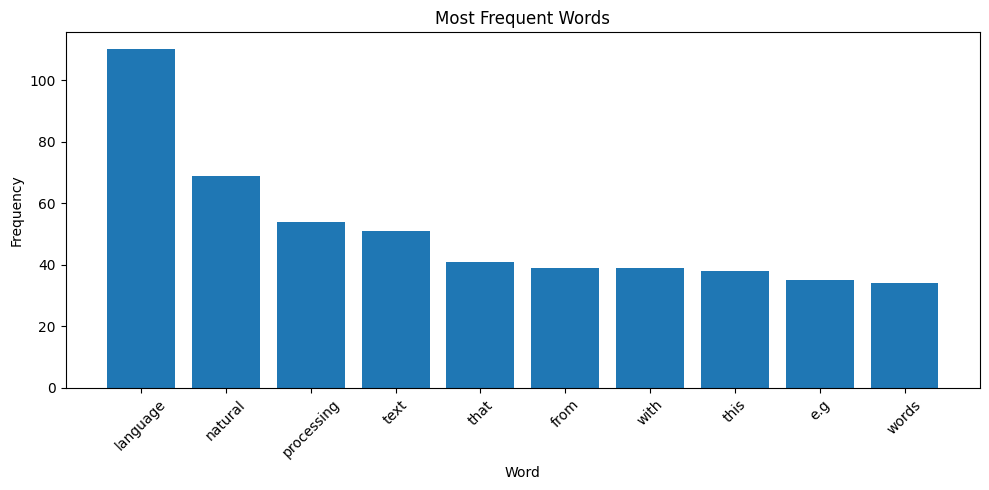

In [23]:
# Section 7 Python cell

# Focus on the 10 most common words for a simple bar chart.
# Use head(10) to get the top 10 rows of the frequency DataFrame.
top_df: pl.DataFrame = freq_df.head(10)

# Make the figure size larger for better readability.
# 10 inches wide by 5 inches tall is a common size for bar charts.
plt.figure(figsize=(10, 5))

# Set the x-axis to the "word" column (the unique words).
# Set the y-axis to the "len" column (the counts).
plt.bar(top_df["word"], top_df["len"])

# Define ax as the current axes (gca = get current axes)
# so we'll be able to modify tick parameters.
ax = plt.gca()

# Set the tick labels on the x-axis
# to rotate 45 degrees for better readability,
ax.tick_params(axis="x", labelrotation=45)

plt.title("Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Section 8. Build a Word Cloud

This is a Markdown cell.

Sample of word frequencies:
language: 110
natural: 69
processing: 54
text: 51
that: 41
from: 39
with: 39
this: 38
e.g: 35
words: 34


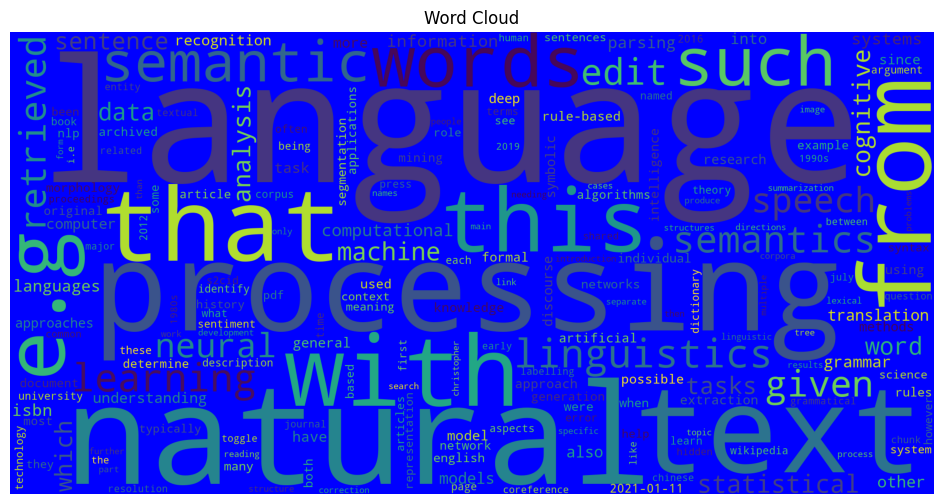

In [24]:
# Section 8 Python cell

# For this, we want a Python dictionary
# mapping words to their frequencies.
# We can use the zip() function to combine the "word" and "len" columns into a dictionary.
# First, convert the frequency dfs to lists with to_list(),
# then zip() them together into a dictionary.
# strict=True ensures both lists are the same length.
freq_dict: dict[str, int] = dict(
    zip(freq_df["word"].to_list(), freq_df["len"].to_list(), strict=True)
)
print("Sample of word frequencies:")
for word, freq in list(freq_dict.items())[:10]:
    print(f"{word}: {freq}")

# Build a word cloud where larger words occur more frequently in the text.
# Set width and height in pixels and set the background color.
wc: WordCloud = WordCloud(width=2000, height=1000, background_color="Blue")

# Generate the word cloud from the frequency dictionary.
wc.generate_from_frequencies(freq_dict)

# Set the figure size in inches
plt.figure(figsize=(12, 6))

# Display the word cloud image with imshow() and turn off axes for a cleaner look.
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

## Reminder: "Run All" before sending to GitHub

Before saving a notebook (and running git add-commit-push),
**click 'Run All'** to generate all outputs and display them in the notebook. 

After git add-commit-push, **verify your notebook appears** in your GitHub repo. 

This is a Markdown cell.
